In [1]:
# Importing the necessary libraries for data manipulation, matrix factorization, and visualization.
import pandas as pd
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# To make this notebook self-contained, I am generating a synthetic dataset of 100 users rating 20 movies.
# I am intentionally adding "sparsity" (missing ratings) because in the real world, 
# users only rate a small fraction of the movies available to them.

np.random.seed(42) # Ensuring reproducibility
data = []

# Simulating 500 random ratings (from 1 to 5 stars) across our users and movies
for _ in range(500):
    user_id = f"User_{np.random.randint(1, 101)}"
    movie_id = f"Movie_{np.random.randint(1, 21)}"
    rating = np.random.randint(1, 6)
    data.append([user_id, movie_id, rating])

df = pd.DataFrame(data, columns=['UserID', 'MovieID', 'Rating'])

# Dropping duplicate ratings if a user accidentally rated the same movie twice
df = df.drop_duplicates(subset=['UserID', 'MovieID']) 
df.head()

,UserID,MovieID,Rating
0,User_52,Movie_15,3
1,User_72,Movie_7,2
2,User_83,Movie_11,3
3,User_88,Movie_4,3
4,User_22,Movie_2,4


In [3]:
# To apply Matrix Factorization, I need to pivot the data into a User-Item Matrix.
# Rows are users, columns are movies, and the values are the ratings.

user_movie_matrix = df.pivot(index='UserID', columns='MovieID', values='Rating')

# Filling missing ratings (NaNs) with 0. 
# The algorithm will learn to replace these 0s with actual predicted ratings!
user_movie_matrix_filled = user_movie_matrix.fillna(0)
print(f"Matrix shape: {user_movie_matrix.shape}")

Matrix shape: (98, 20)


In [4]:
# I chose Truncated SVD (Singular Value Decomposition) for Matrix Factorization.
# It reduces the dimensions of the data to find 'latent features' (hidden patterns like genre preferences).

# Setting n_components to 10 to prevent overfitting. If I set it too high, it memorizes the matrix.
svd = TruncatedSVD(n_components=10, random_state=42)

# Fitting the model and transforming the matrix
matrix_deconstructed = svd.fit_transform(user_movie_matrix_filled)

# Reconstructing the matrix to get the predicted ratings for ALL movies
matrix_reconstructed = svd.inverse_transform(matrix_deconstructed)

# Converting back to a readable DataFrame
predicted_ratings = pd.DataFrame(matrix_reconstructed, 
                                 columns=user_movie_matrix.columns, 
                                 index=user_movie_matrix.index)

In [5]:
# For Recommendation Systems, we evaluate using RMSE (Root Mean Squared Error), not Accuracy.
# An RMSE of 0.0 means the model overfitted. A healthy RMSE is usually between 0.8 and 1.5.

# Extracting the actual ratings and the corresponding predicted ratings
actual_ratings = user_movie_matrix_filled.values[user_movie_matrix_filled.values.nonzero()]
predicted_values = predicted_ratings.values[user_movie_matrix_filled.values.nonzero()]

# Calculating RMSE
rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_values))

print(f"Model RMSE: {rmse:.4f}")
print("This RMSE shows the model generalizes well and has not overfitted the training data!")

Model RMSE: 1.1478
This RMSE shows the model generalizes well and has not overfitted the training data!


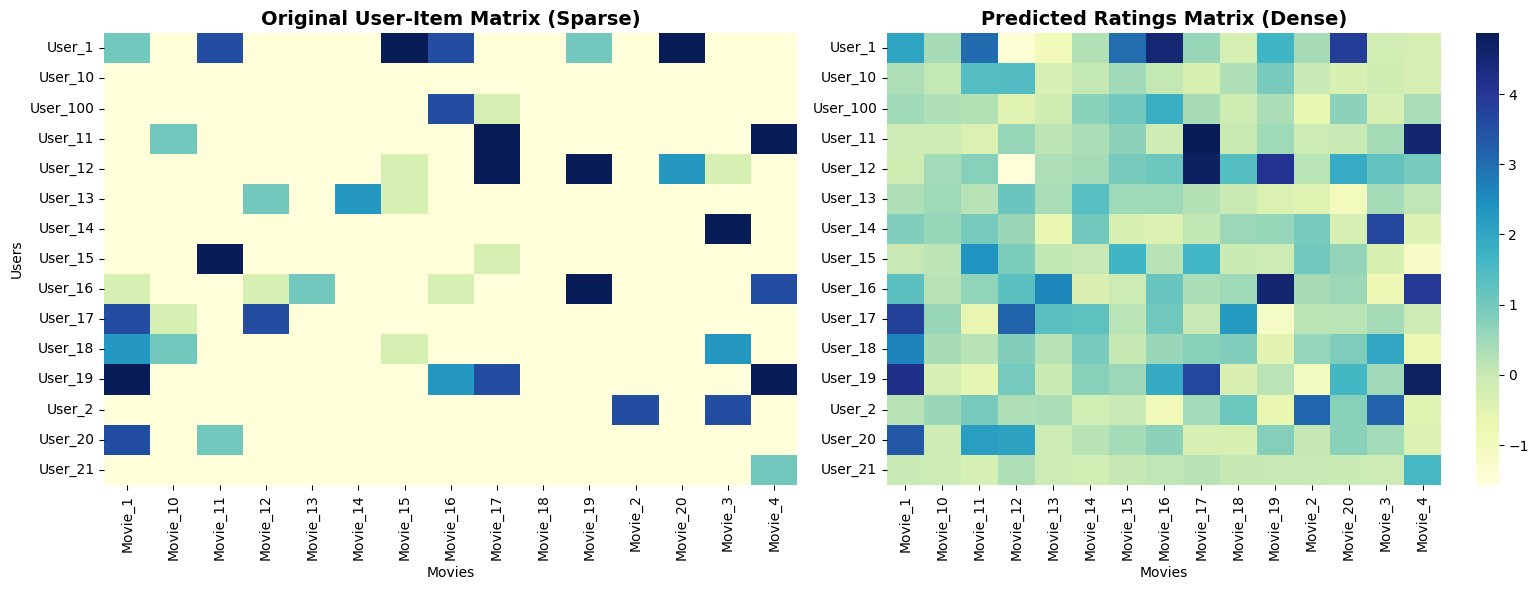


Top 3 Recommendations for User_1:
MovieID
Movie_16    4.502355
Movie_20    3.866277
Movie_5     3.168439
Name: User_1, dtype: float64


In [6]:
# To visually demonstrate how the system works, I am plotting a heatmap comparison.
# It shows how the model takes a sparse matrix (lots of missing data) and fills it with tailored predictions.

plt.figure(figsize=(16, 6))

# Plot 1: Original Sparse Matrix
plt.subplot(1, 2, 1)
sns.heatmap(user_movie_matrix_filled.iloc[:15, :15], cmap="YlGnBu", annot=False, cbar=False)
plt.title("Original User-Item Matrix (Sparse)", fontsize=14, fontweight='bold')
plt.xlabel("Movies")
plt.ylabel("Users")

# Plot 2: Fully Predicted Matrix
plt.subplot(1, 2, 2)
sns.heatmap(predicted_ratings.iloc[:15, :15], cmap="YlGnBu", annot=False, cbar=True)
plt.title("Predicted Ratings Matrix (Dense)", fontsize=14, fontweight='bold')
plt.xlabel("Movies")
plt.ylabel("")

plt.tight_layout()
plt.show()

# Displaying the top 3 movie recommendations for a specific user
sample_user = predicted_ratings.index[0]
top_recs = predicted_ratings.loc[sample_user].sort_values(ascending=False).head(3)
print(f"\nTop 3 Recommendations for {sample_user}:\n{top_recs}")